# CMPUT 328 — Assignment 1
## Logistic Regression (MNIST) and Fully Connected Neural Networks (CIFAR-10)

**Total weight:** 9% of the course grade — Part 1 (MNIST) 4% + Part 2 (CIFAR-10) 5%
**Deadline:** 21 September 2026, 11:59 PM (MST)

**Submit:** this notebook with all outputs and plots visible, **and** a 1–2 page PDF report.
Put your name and student ID on both. If you use Gemini or another AI assistant, document it in the report.

---

### How this notebook is organised

One pipeline is shared by every experiment in both parts. The same `Classifier` class covers MNIST
logistic regression, CIFAR-10 logistic regression and the CIFAR-10 fully connected network — only the
input dimension and the `hidden_sizes` argument change:

| | `in_dim` | `hidden_sizes` |
|---|---|---|
| MNIST logistic regression | `28*28` | `()` |
| CIFAR-10 logistic regression | `3*32*32` | `()` |
| CIFAR-10 FFNN | `3*32*32` | `(512,)` |

The training loop, evaluation and plotting code is written **once**. If you find yourself copy-pasting a
training loop, stop — you are meant to call the same `build_and_fit()` with different arguments.

### What you have to fill in

Look for `### TODO`. They are:

1. `Classifier.__init__` — the layer stack
2. `run_epoch` — one train/eval pass, including the optional L1 penalty
3. `confusion_matrix`
4. `show_misclassified`
5. The CIFAR-10 data loaders
6. The experiment cells in Parts 1 and 2

Everything else is provided. Do not rename the provided functions.

**Name:** Laurie Gantuangco **Student ID:** 1771419

## 0 · Setup

`FAST_MODE` trains on a random subset of each training set so the whole notebook finishes inside the lab.
Leave it on if you are short on time — but **state in your report which setting you used**, and keep it
the same across every comparison, otherwise your runs are not comparable to each other.

In [25]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset, random_split
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

SEED = 328
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed()

# ---- speed controls -------------------------------------------------------
FAST_MODE = True                    # set to False to train on the full datasets

MNIST_TRAIN_FRACTION = 0.25 if FAST_MODE else 1.0
CIFAR_TRAIN_FRACTION = 0.50 if FAST_MODE else 1.0
EPOCHS_MNIST         = 10   if FAST_MODE else 15
EPOCHS_CIFAR         = 12   if FAST_MODE else 15

BATCH_SIZE = 256
VAL_SIZE   = 5_000
ROOT       = "./data"

print(f"FAST_MODE={FAST_MODE} | MNIST train fraction {MNIST_TRAIN_FRACTION} "
      f"({EPOCHS_MNIST} epochs) | CIFAR train fraction {CIFAR_TRAIN_FRACTION} "
      f"({EPOCHS_CIFAR} epochs)")

Using device: cpu
FAST_MODE=True | MNIST train fraction 0.25 (10 epochs) | CIFAR train fraction 0.5 (12 epochs)


In [26]:
def subset(ds, fraction, seed=SEED):
    """Random subset of `ds`. fraction=1.0 returns the dataset unchanged."""
    if fraction >= 1.0:
        return ds
    n = int(len(ds) * fraction)
    g = torch.Generator().manual_seed(seed)
    idx = torch.randperm(len(ds), generator=g)[:n].tolist()
    return Subset(ds, idx)


def get_targets(ds):
    """Integer labels of a dataset, unwrapping any number of nested Subsets."""
    if isinstance(ds, Subset):
        return get_targets(ds.dataset)[torch.as_tensor(ds.indices)]
    return torch.as_tensor(ds.targets)

## 1 · Data — MNIST (provided)

60,000 training / 10,000 test grayscale digits, 28x28. Flattened, each image is a vector of length 784.
A 5,000-image validation split is carved out of the training set so the test set is used only where the
assignment asks for it (the Part 1 confusion matrix).

In [27]:
MNIST_MEAN = (0.1307,)
MNIST_STD  = (0.3081,)

mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MNIST_MEAN, MNIST_STD),
])

mnist_full_train = datasets.MNIST(ROOT, train=True,  download=True, transform=mnist_transform)
mnist_test_ds    = datasets.MNIST(ROOT, train=False, download=True, transform=mnist_transform)

mnist_train_full, mnist_val_ds = random_split(
    mnist_full_train, [len(mnist_full_train) - VAL_SIZE, VAL_SIZE],
    generator=torch.Generator().manual_seed(SEED)
)
mnist_train_ds = subset(mnist_train_full, MNIST_TRAIN_FRACTION)

mnist_train_loader = DataLoader(mnist_train_ds, batch_size=BATCH_SIZE, shuffle=True,
                                num_workers=2, pin_memory=True)
mnist_val_loader   = DataLoader(mnist_val_ds,  batch_size=BATCH_SIZE, shuffle=False,
                                num_workers=2, pin_memory=True)
mnist_test_loader  = DataLoader(mnist_test_ds, batch_size=BATCH_SIZE, shuffle=False,
                                num_workers=2, pin_memory=True)

MNIST_CLASSES = tuple(str(i) for i in range(10))

print(f"MNIST  train {len(mnist_train_ds)} | val {len(mnist_val_ds)} | test {len(mnist_test_ds)}")

MNIST  train 13750 | val 5000 | test 10000


/home/laurie/CMPUT328/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


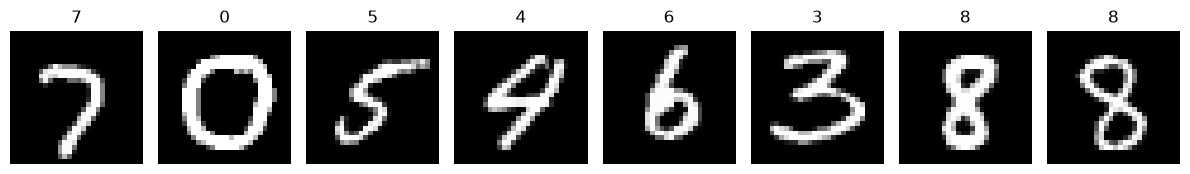

Batch shape: torch.Size([256, 1, 28, 28]) -> flattened: torch.Size([256, 784])


In [28]:
def denormalize_mnist(img):
    mean = torch.tensor(MNIST_MEAN).view(1, 1, 1)
    std  = torch.tensor(MNIST_STD).view(1, 1, 1)
    return (img.cpu() * std + mean).clamp(0, 1)

def show_mnist_examples(loader, n=8):
    images, labels = next(iter(loader))
    fig, axes = plt.subplots(1, n, figsize=(1.5 * n, 2))
    for ax, img, label in zip(axes, images[:n], labels[:n]):
        ax.imshow(denormalize_mnist(img).squeeze().numpy(), cmap="gray")
        ax.set_title(str(int(label))); ax.axis("off")
    plt.tight_layout(); plt.show()
    print("Batch shape:", images.shape, "-> flattened:", images.flatten(1).shape)

show_mnist_examples(mnist_train_loader)

## 2 · Data — CIFAR-10  *(graded: Data Pipeline, 0.25%)*

50,000 training / 10,000 test colour images, 32x32x3 — flattened, a vector of length 3072. Build the
three loaders below.

Note what flattening costs you: the model never learns that two pixels are neighbours. That is the
reason a fully connected network struggles here, and the reason CNNs exist.

In [29]:
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

cifar_full_train = datasets.CIFAR10(ROOT, train=True,  download=True, transform=transform)
cifar_test_ds    = datasets.CIFAR10(ROOT, train=False, download=True, transform=transform)

### TODO 5a: split `cifar_full_train` into a training set and a VAL_SIZE validation set.
### Use random_split with generator=torch.Generator().manual_seed(SEED) so your split is reproducible.
cifar_train_full, cifar_val_ds = torch.utils.data.random_split(cifar_full_train, [len(cifar_full_train) - VAL_SIZE, VAL_SIZE], generator=torch.Generator().manual_seed(SEED))

cifar_train_ds = subset(cifar_train_full, CIFAR_TRAIN_FRACTION)

### TODO 5b: build the three loaders.
### Batch size BATCH_SIZE. Shuffle the training loader only — shuffling at evaluation time buys nothing
### and makes the confusion matrix non-reproducible.
train_loader = torch.utils.data.DataLoader(cifar_train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = torch.utils.data.DataLoader(cifar_val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = torch.utils.data.DataLoader(cifar_test_ds, batch_size=BATCH_SIZE, shuffle=False)

CLASSES = tuple(cifar_full_train.classes)

print(f"CIFAR-10  train {len(cifar_train_ds)} | val {len(cifar_val_ds)} | test {len(cifar_test_ds)}")
print("classes:", CLASSES)

CIFAR-10  train 22500 | val 5000 | test 10000
classes: ('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


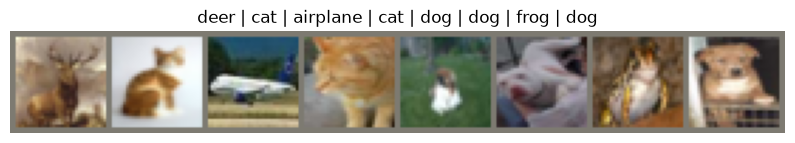

Batch shape: torch.Size([256, 3, 32, 32]) -> flattened: torch.Size([256, 3072])


In [30]:
def denormalize(img):
    mean = torch.tensor(CIFAR_MEAN).view(3, 1, 1)
    std  = torch.tensor(CIFAR_STD).view(3, 1, 1)
    return (img.cpu() * std + mean).clamp(0, 1)

def imshow(img, ax=None):
    ax = ax or plt.gca()
    ax.imshow(denormalize(img).permute(1, 2, 0).numpy())
    ax.axis("off")

images, labels = next(iter(train_loader))
plt.figure(figsize=(10, 2))
imshow(utils.make_grid(images[:8], nrow=8))
plt.title(" | ".join(CLASSES[l] for l in labels[:8]))
plt.show()
print("Batch shape:", images.shape, "-> flattened:", images.flatten(1).shape)

## 3 · The shared pipeline

### 3.1 One model class for every model

$$
\text{Logistic regression:}\quad z = Wx + b
\qquad\qquad
\text{FFNN (one hidden layer):}\quad z = W_2\,\sigma(W_1 x + b_1) + b_2
$$

Both return raw **logits** — no softmax at the end. `nn.CrossEntropyLoss` applies the log-softmax
internally, and applying it yourself as well is both wrong and numerically worse.

In [31]:
class Classifier(nn.Module):
    """Flatten -> [Linear -> activation] * len(hidden_sizes) -> Linear -> logits.

    hidden_sizes=() must reduce to a single nn.Linear(in_dim, num_classes),
    i.e. multinomial logistic regression.
    """
    def __init__(self, in_dim, num_classes=10, hidden_sizes=(), activation=nn.ReLU):
        super().__init__()
        ### TODO 1: build `self.net` as an nn.Sequential.
        ### Walk through hidden_sizes adding nn.Linear(prev, h) followed by activation(),
        ### then finish with a final nn.Linear(prev, num_classes).
        layers, prev = [], in_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            layers.append(activation())
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x.flatten(1))


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Run these checks once TODO 1 is done -- they catch the usual mistakes immediately.
set_seed()
_m = Classifier(28*28)
assert len(_m.net) == 1 and isinstance(_m.net[0], nn.Linear), "hidden_sizes=() must be one Linear"
assert _m(torch.randn(4, 1, 28, 28)).shape == (4, 10)
assert Classifier(3*32*32, hidden_sizes=(512,))(torch.randn(4, 3, 32, 32)).shape == (4, 10)
print("MNIST LogReg    :", f"{count_params(Classifier(28*28)):,} params")
print("CIFAR-10 LogReg :", f"{count_params(Classifier(3*32*32)):,} params")
print("CIFAR-10 FFNN   :", f"{count_params(Classifier(3*32*32, hidden_sizes=(512,))):,} params")

MNIST LogReg    : 7,850 params
CIFAR-10 LogReg : 30,730 params
CIFAR-10 FFNN   : 1,578,506 params


### 3.2 One training loop for every experiment

`run_epoch` does **both** training and evaluation: with `optimizer=None` it runs under `no_grad` in eval
mode, otherwise it takes gradient steps.

It also carries the **L1** hook you need in Part 1.2. L2 does not appear here at all — it is passed to the
optimizer as `weight_decay`, which adds the gradient of $\tfrac{\lambda}{2}\lVert w \rVert_2^2$ for you.
L1 has no such switch, so you add $\lambda \lVert w \rVert_1$ to the loss by hand and let autograd
differentiate it.

In [32]:
def run_epoch(model, loader, criterion, optimizer=None, l1_lambda=0.0):
    """One pass over `loader`. Returns (average_loss, accuracy).

    optimizer=None -> evaluation pass (no gradients, model.eval()).
    l1_lambda > 0  -> add l1_lambda * sum(|w|) to the training loss.
    """
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train_mode):
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

            ### TODO 2: implement one step.
            logits = model(x)
            loss = criterion(logits, y)
            if train_mode and l1_lambda > 0:
                l1_loss = sum(p.abs().sum() for p in model.parameters() if p.requires_grad)
                loss += l1_lambda * l1_loss
            if train_mode:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            ### 5. accumulate total_loss (loss.item() * y.size(0)), correct, and n
            total_loss += loss.item() * y.size(0)
            with torch.no_grad():
                pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()
            n += y.size(0)

    return total_loss / n, correct / n

In [33]:
# --- provided: do not modify ------------------------------------------------
def fit(model, criterion, optimizer, train_loader, val_loader, epochs=15,
        label="", l1_lambda=0.0, verbose=True):
    history = {"label": label, "train_loss": [], "val_loss": [],
               "train_acc": [], "val_acc": []}
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, l1_lambda=l1_lambda)
        va_loss, va_acc = run_epoch(model, val_loader, criterion)
        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc)
        if verbose:
            print(f"epoch {epoch:02d}  train loss {tr_loss:.4f} acc {tr_acc:.3f}  |  "
                  f"val loss {va_loss:.4f} acc {va_acc:.3f}")
    return history


def build_and_fit(in_dim, train_loader, val_loader, hidden_sizes=(),
                  optim_name="sgd", lr=0.01, epochs=15,
                  weight_decay=0.0, l1_lambda=0.0, label=None, **kwargs):
    """One call = one experiment. Re-seeds first, so differences between runs come from
    the arguments you changed and not from the initialization."""
    set_seed()
    model = Classifier(in_dim=in_dim, hidden_sizes=hidden_sizes).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = {
        "sgd":  lambda: torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9,
                                        weight_decay=weight_decay),
        "adam": lambda: torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay),
    }[optim_name]()

    label = label or (f"{'LR' if not hidden_sizes else 'FFNN'+str(list(hidden_sizes))}"
                      f"|CE|{optim_name}|lr={lr}")
    print(f"{label}  ({count_params(model):,} parameters)")
    history = fit(model, criterion, optimizer, train_loader, val_loader,
                  epochs=epochs, label=label, l1_lambda=l1_lambda, **kwargs)
    return model, history

### 3.3 Evaluation and plotting helpers

In [34]:
@torch.no_grad()
def predict_all(model, loader):
    """(y_true, y_pred) over the whole loader, as CPU int tensors."""
    model.eval()
    ys, ps = [], []
    for x, y in loader:
        ps.append(model(x.to(device)).argmax(1).cpu()); ys.append(y)
    return torch.cat(ys), torch.cat(ps)


def plot_curves(histories, title=""):
    """Loss (left) and accuracy (right); train solid, validation dashed."""
    if isinstance(histories, dict):
        histories = [histories]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for h in histories:
        ep = range(1, len(h["train_loss"]) + 1)
        axes[0].plot(ep, h["train_loss"], label=f"{h['label']} train")
        axes[0].plot(ep, h["val_loss"], "--", label=f"{h['label']} val")
        axes[1].plot(ep, h["train_acc"], label=f"{h['label']} train")
        axes[1].plot(ep, h["val_acc"], "--", label=f"{h['label']} val")
    axes[0].set(xlabel="epoch", ylabel="loss", title="Loss")
    axes[1].set(xlabel="epoch", ylabel="accuracy", title="Accuracy")
    for a in axes:
        a.grid(alpha=.3); a.legend(fontsize=8)
    fig.suptitle(title); plt.tight_layout(); plt.show()


def confusion_matrix(y_true, y_pred, num_classes=10):
    """Return a (num_classes, num_classes) integer tensor; rows = true, cols = predicted."""
    ### TODO 3: plain tensor ops, no sklearn.
    cm = torch.bincount(y_true * num_classes + y_pred, minlength=num_classes**2).reshape(num_classes, num_classes)
    ### Hint: either loop over the pairs and increment cm[t, p],
    ### or torch.bincount(y_true * num_classes + y_pred, minlength=num_classes**2).reshape(...)
    return cm


def plot_confusion(cm, classes, normalize=True, title="Confusion matrix"):
    m = cm.float()
    if normalize:
        m = m / m.sum(1, keepdim=True).clamp(min=1)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(m, cmap="Blues")
    ax.set(xticks=range(len(classes)), yticks=range(len(classes)),
           xlabel="predicted", ylabel="true", title=title)
    ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.set_yticklabels(classes)
    for i in range(len(classes)):
        for j in range(len(classes)):
            v = m[i, j].item()
            ax.text(j, i, f"{v:.2f}" if normalize else int(v), ha="center", va="center",
                    fontsize=7, color="white" if v > m.max().item() * .6 else "black")
    fig.colorbar(im); plt.tight_layout(); plt.show()


def top_confusions(cm, classes, k=5):
    """The k largest off-diagonal (true -> predicted) counts. Useful for the discussion."""
    m = cm.clone(); m.fill_diagonal_(0)
    vals, idxs = m.flatten().topk(k)
    return [(classes[int(i) // len(classes)], classes[int(i) % len(classes)], int(v))
            for v, i in zip(vals, idxs)]

In [35]:
@torch.no_grad()
def show_misclassified(model, loader, n=16, classes=CLASSES):
    """Grid of at least `n` misclassified images, titled with predicted and true labels.

    Written for CIFAR-10 (uses the 3-channel `imshow` above).
    """
    model.eval()
    
    misclassified = []

    for images, labels in loader:
        predictions = model(images.to(device)).argmax(dim=1).cpu()

        for image, true_label, pred_label in zip(images, labels, predictions):
            if pred_label != true_label:
                misclassified.append((image, int(true_label), int(pred_label)))
                if len(misclassified) >= n:
                    break

        if len(misclassified) >= n:
            break

    if not misclassified:
        print("No misclassified images found.")
        return

    misclassified = misclassified[:n]
    cols = 8
    rows = (len(misclassified) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2.5 * rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, (image, true_label, pred_label) in zip(axes, misclassified):
        imshow(image, ax=ax)
        ax.set_title(f"p: {classes[pred_label]}\nt: {classes[true_label]}")

    for ax in axes[len(misclassified):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

---
# PART 1 — Logistic Regression on MNIST (4%)

Suggested settings, used consistently across every comparison below:
**SGD lr=0.01 (momentum 0.9)**, **Adam lr=0.001**, `EPOCHS_MNIST` epochs, batch size 256.

Change **one thing at a time**. `build_and_fit` re-seeds before every run, so any difference you see
comes from the argument you changed.

### 1.1 · Baseline logistic regression (SGD + cross-entropy)  *(0.5%)*

Multinomial logistic regression on flattened pixels. With softmax $p_k = e^{z_k}/\sum_j e^{z_j}$ and
cross-entropy $\mathcal{L} = -\log p_y$, the gradient w.r.t. the logits is $\hat p - e_y$ — the residual
between the predicted distribution and the one-hot target. The objective is **convex**, so the optimizer
affects how fast you arrive, not where.

Complete TODOs 1 and 2 first, then run this cell.

MNIST LogReg|CE|SGD|lr=0.01  (7,850 parameters)
epoch 01  train loss 0.6855 acc 0.784  |  val loss 0.3952 acc 0.890
epoch 02  train loss 0.3573 acc 0.897  |  val loss 0.3539 acc 0.899
epoch 03  train loss 0.3261 acc 0.906  |  val loss 0.3430 acc 0.906
epoch 04  train loss 0.3094 acc 0.912  |  val loss 0.3399 acc 0.907
epoch 05  train loss 0.2976 acc 0.915  |  val loss 0.3298 acc 0.909
epoch 06  train loss 0.2890 acc 0.918  |  val loss 0.3307 acc 0.909
epoch 07  train loss 0.2804 acc 0.920  |  val loss 0.3275 acc 0.911
epoch 08  train loss 0.2768 acc 0.922  |  val loss 0.3265 acc 0.911
epoch 09  train loss 0.2708 acc 0.922  |  val loss 0.3244 acc 0.912
epoch 10  train loss 0.2663 acc 0.922  |  val loss 0.3235 acc 0.911
MNIST LogReg|CE|SGD|lr=0.01  (7,850 parameters)
epoch 01  train loss 0.6855 acc 0.784  |  val loss 0.3952 acc 0.890
epoch 02  train loss 0.3573 acc 0.897  |  val loss 0.3539 acc 0.899
epoch 03  train loss 0.3261 acc 0.906  |  val loss 0.3430 acc 0.906
epoch 04  train loss

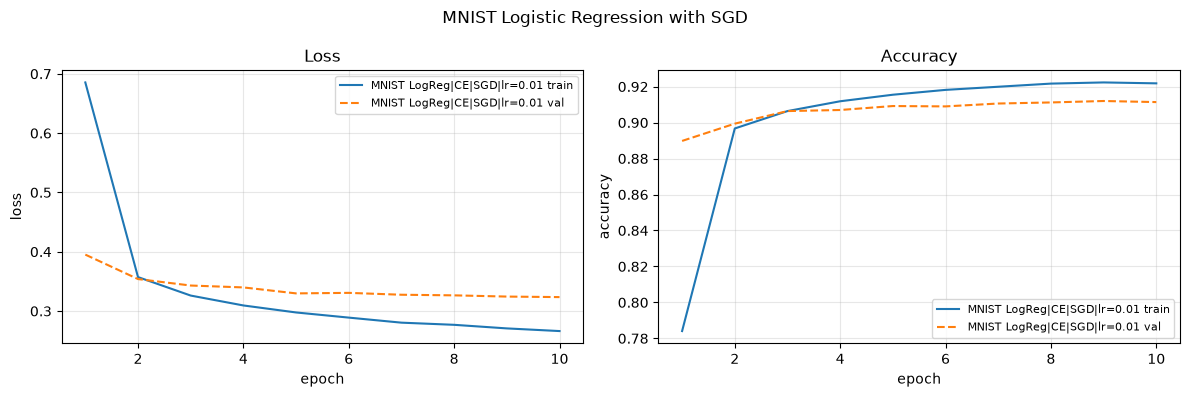

Final validation accuracy: 0.9114


In [36]:
LR = {"sgd": 0.01, "adam": 0.001}

### TODO: train the baseline with build_and_fit(in_dim=28*28, train_loader=mnist_train_loader,
###       val_loader=mnist_val_loader, optim_name="sgd", lr=LR["sgd"], epochs=EPOCHS_MNIST, label=...)
###       then plot_curves(...) and state the final validation accuracy.
build_and_fit(in_dim=28*28, train_loader=mnist_train_loader, val_loader=mnist_val_loader,
              optim_name="sgd", lr=LR["sgd"], epochs=EPOCHS_MNIST, label="MNIST LogReg|CE|SGD|lr=0.01")
mnist_lr_sgd, h_mnist_lr_sgd = build_and_fit(
    in_dim=28 * 28,
    train_loader=mnist_train_loader,
    val_loader=mnist_val_loader,
    optim_name="sgd",
    lr=LR["sgd"],
    epochs=EPOCHS_MNIST,
    label="MNIST LogReg|CE|SGD|lr=0.01",
)

plot_curves(h_mnist_lr_sgd, title="MNIST Logistic Regression with SGD")
print("Final validation accuracy:",
      h_mnist_lr_sgd["val_acc"][-1])

The baseline reached a final validation accuracy of 91.14%. Training accuracy increased steadily from 78.4% to 92.2%, while validation accuracy improved quickly before leveling off at about 91%; the widening gap near the end suggests mild overfitting.

### 1.2 · Regularization: L2 vs. L1  *(0.5%)*

Train the same model twice more, changing only the regularizer:

- **L2** — pass `weight_decay=...` to `build_and_fit`. Penalty $\tfrac{\lambda}{2}\lVert w\rVert_2^2$;
  its gradient $\lambda w$ shrinks every weight in proportion to its size, so weights get small but
  stay non-zero.
- **L1** — pass `l1_lambda=...`. Penalty $\lambda\lVert w\rVert_1$; its gradient is $\lambda\,\text{sign}(w)$,
  a constant pull toward zero regardless of magnitude, which drives small weights exactly to zero and
  gives you a **sparse** weight matrix.

Suggested starting points: `weight_decay=5e-4`, `l1_lambda=1e-5`. Other values are fine — state what you used.
Compare on validation accuracy, and also report how many weights each run leaves near zero
(e.g. the fraction of $|w| < 10^{-3}$), which is where the two differ most visibly.

MNIST LogReg|L2|lambda=0.0005  (7,850 parameters)
epoch 01  train loss 0.6854 acc 0.784  |  val loss 0.3952 acc 0.890
epoch 02  train loss 0.3573 acc 0.897  |  val loss 0.3541 acc 0.899
epoch 03  train loss 0.3263 acc 0.906  |  val loss 0.3432 acc 0.906
epoch 04  train loss 0.3098 acc 0.912  |  val loss 0.3401 acc 0.907
epoch 05  train loss 0.2980 acc 0.915  |  val loss 0.3300 acc 0.909
epoch 06  train loss 0.2894 acc 0.918  |  val loss 0.3308 acc 0.909
epoch 07  train loss 0.2810 acc 0.920  |  val loss 0.3276 acc 0.911
epoch 08  train loss 0.2774 acc 0.922  |  val loss 0.3266 acc 0.911
epoch 09  train loss 0.2715 acc 0.922  |  val loss 0.3245 acc 0.912
epoch 10  train loss 0.2670 acc 0.922  |  val loss 0.3235 acc 0.912
MNIST LogReg|L1|lambda=1e-05  (7,850 parameters)
epoch 01  train loss 0.6872 acc 0.784  |  val loss 0.3952 acc 0.890
epoch 02  train loss 0.3593 acc 0.897  |  val loss 0.3540 acc 0.899
epoch 03  train loss 0.3283 acc 0.906  |  val loss 0.3431 acc 0.906
epoch 04  train l

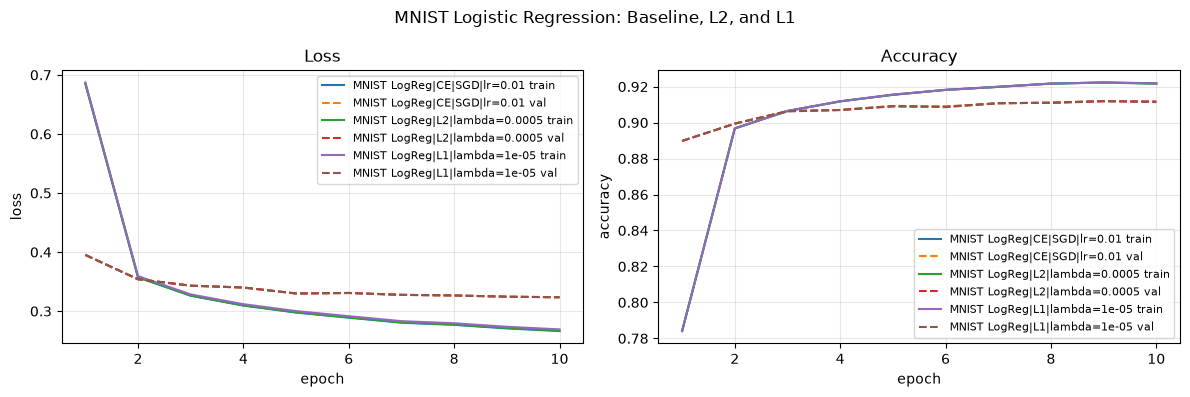

Baseline: final val acc=0.9114, best val acc=0.9120 (epoch 9), near-zero fraction=0.0204
L2: final val acc=0.9118, best val acc=0.9118 (epoch 9), near-zero fraction=0.0208
L1: final val acc=0.9114, best val acc=0.9120 (epoch 9), near-zero fraction=0.0239


In [37]:
L2_WEIGHT_DECAY = 5e-4
L1_LAMBDA = 1e-5

mnist_lr_l2, h_mnist_lr_l2 = build_and_fit(
    in_dim=28 * 28,
    train_loader=mnist_train_loader,
    val_loader=mnist_val_loader,
    optim_name="sgd",
    lr=LR["sgd"],
    epochs=EPOCHS_MNIST,
    weight_decay=L2_WEIGHT_DECAY,
    label=f"MNIST LogReg|L2|lambda={L2_WEIGHT_DECAY}",
)

mnist_lr_l1, h_mnist_lr_l1 = build_and_fit(
    in_dim=28 * 28,
    train_loader=mnist_train_loader,
    val_loader=mnist_val_loader,
    optim_name="sgd",
    lr=LR["sgd"],
    epochs=EPOCHS_MNIST,
    l1_lambda=L1_LAMBDA,
    label=f"MNIST LogReg|L1|lambda={L1_LAMBDA}",
)

plot_curves(
    [h_mnist_lr_sgd, h_mnist_lr_l2, h_mnist_lr_l1],
    title="MNIST Logistic Regression: Baseline, L2, and L1",
)


def near_zero_fraction(model, threshold=1e-3):
    parameters = torch.cat([p.detach().flatten().cpu() for p in model.parameters()])
    return (parameters.abs() < threshold).float().mean().item()

for name, model, history in [
    ("Baseline", mnist_lr_sgd, h_mnist_lr_sgd),
    ("L2", mnist_lr_l2, h_mnist_lr_l2),
    ("L1", mnist_lr_l1, h_mnist_lr_l1),
]:
    best_epoch = int(np.argmax(history["val_acc"])) + 1
    print(
        f"{name}: final val acc={history['val_acc'][-1]:.4f}, "
        f"best val acc={max(history['val_acc']):.4f} (epoch {best_epoch}), "
        f"near-zero fraction={near_zero_fraction(model):.4f}"
    )

At the chosen strengths, L2 gave the slightly higher final validation accuracy (91.18%), while L1 matched the baseline (91.14%); the best validation accuracies were effectively tied at about 91.2%. The training and validation curves nearly overlap across all three runs, so neither regularizer produced a meaningful accuracy improvement in this experiment. L1 left the largest fraction of parameters near zero (2.39%, compared with 2.08% for L2 and 2.04% for the baseline), showing the expected modest increase in sparsity.

### 1.3 · Optimizer comparison: SGD vs. Adam  *(0.5%)*

Same model, same loss, same epochs — change only the optimizer. SGD with momentum uses one global step
size; Adam adapts a step size per parameter from running estimates of the gradient's first and second
moments.

Judge **convergence speed** and **final accuracy** separately: the interesting case is when one wins on
one and loses on the other. Use a learning rate appropriate to each optimizer (Adam at 0.01 is usually
unstable) and **state both values** — comparing them at the same learning rate is a methodology error,
not a finding.

MNIST LogReg|CE|Adam|lr=0.001  (7,850 parameters)
epoch 01  train loss 0.9921 acc 0.718  |  val loss 0.5315 acc 0.864
epoch 02  train loss 0.4558 acc 0.878  |  val loss 0.4203 acc 0.887
epoch 03  train loss 0.3855 acc 0.895  |  val loss 0.3823 acc 0.896
epoch 04  train loss 0.3501 acc 0.902  |  val loss 0.3615 acc 0.901
epoch 05  train loss 0.3277 acc 0.907  |  val loss 0.3449 acc 0.907
epoch 06  train loss 0.3123 acc 0.913  |  val loss 0.3379 acc 0.906
epoch 07  train loss 0.2992 acc 0.915  |  val loss 0.3316 acc 0.911
epoch 08  train loss 0.2914 acc 0.918  |  val loss 0.3284 acc 0.910
epoch 09  train loss 0.2828 acc 0.920  |  val loss 0.3251 acc 0.912
epoch 10  train loss 0.2760 acc 0.922  |  val loss 0.3209 acc 0.914


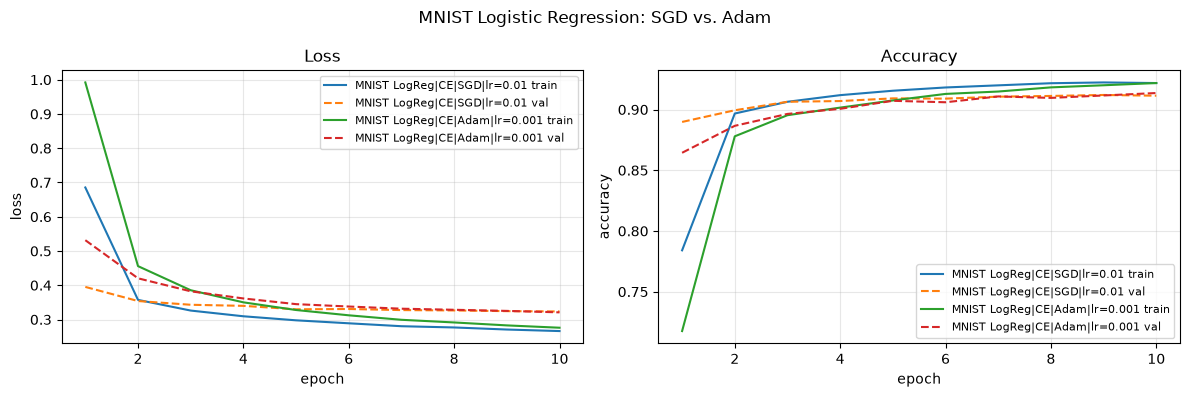

SGD learning rate: 0.01
Adam learning rate: 0.001
Adam epoch-1 validation accuracy: 0.8644
Adam best validation accuracy: 0.9136 (epoch 10)
Adam final validation accuracy: 0.9136


In [38]:
mnist_lr_adam, h_mnist_lr_adam = build_and_fit(
    in_dim=28 * 28,
    train_loader=mnist_train_loader,
    val_loader=mnist_val_loader,
    optim_name="adam",
    lr=LR["adam"],
    epochs=EPOCHS_MNIST,
    label="MNIST LogReg|CE|Adam|lr=0.001",
)

plot_curves(
    [h_mnist_lr_sgd, h_mnist_lr_adam],
    title="MNIST Logistic Regression: SGD vs. Adam",
)

adam_best_epoch = int(np.argmax(h_mnist_lr_adam["val_acc"])) + 1
print(f"SGD learning rate: {LR['sgd']}")
print(f"Adam learning rate: {LR['adam']}")
print(f"Adam epoch-1 validation accuracy: {h_mnist_lr_adam['val_acc'][0]:.4f}")
print(
    f"Adam best validation accuracy: {max(h_mnist_lr_adam['val_acc']):.4f} "
    f"(epoch {adam_best_epoch})"
)
print(f"Adam final validation accuracy: {h_mnist_lr_adam['val_acc'][-1]:.4f}")

SGD converged faster at the beginning: its epoch-1 validation accuracy was 89.04%, compared with 86.44% for Adam. Adam caught up over the later epochs and ended slightly higher, with a final and best validation accuracy of 91.36% at epoch 10, compared with SGD's final 91.14% and best 91.20%. I used learning rates of 0.01 for SGD with momentum and 0.001 for Adam, since Adam is unstable at the larger rate.

### 1.4 · Visualization of learned weights  *(0.5%)*

Row $k$ of $W$ has exactly 784 entries — one per pixel — so it reshapes to 28x28 and can be viewed as an
image. The score for class $k$ is $\langle w_k, x\rangle$, so each row acts as a **template** for that
digit: positive weights mark pixels that argue for the class, negative weights argue against it.

Plot all 10. A diverging colormap centred at zero (`cmap="bwr"` with symmetric limits) shows the sign
structure far better than grayscale.

/tmp/ipykernel_8929/852813400.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


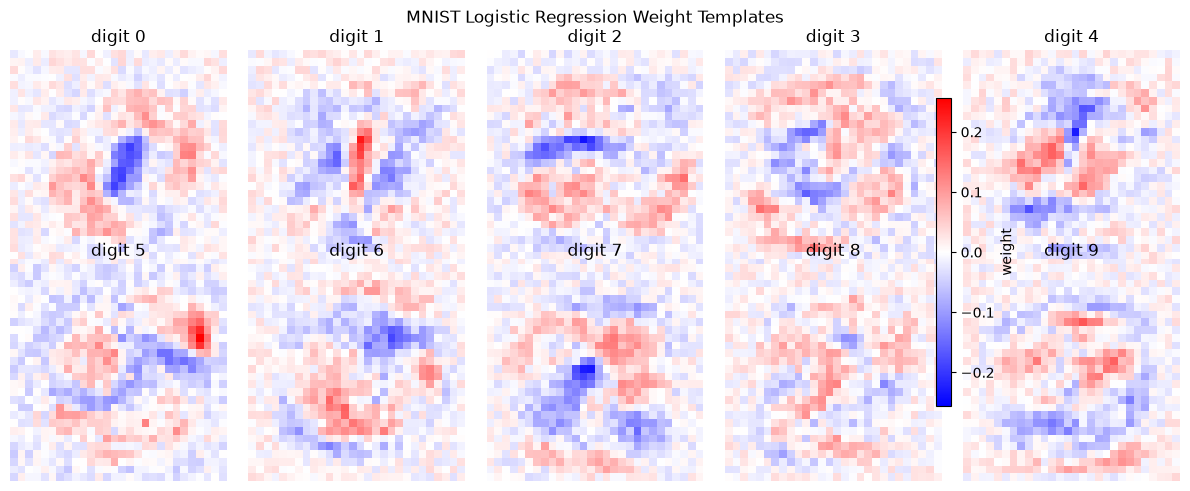

In [39]:
W = mnist_lr_sgd.net[0].weight.detach().cpu()
vmax = W.abs().max().item()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit, ax in enumerate(axes.ravel()):
    image = W[digit].reshape(28, 28)
    im = ax.imshow(image, cmap="bwr", vmin=-vmax, vmax=vmax)
    ax.set_title(f"digit {digit}")
    ax.axis("off")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="weight")
fig.suptitle("MNIST Logistic Regression Weight Templates")
plt.tight_layout()
plt.show()

The templates show rough, recognizable digit shapes, although they are noisy because a linear model must separate classes directly from raw pixels. Positive (red) regions are pixels whose intensity supports the corresponding digit's score, while negative (blue) regions suppress that score and distinguish it from competing digits. The patterns are class-specific rather than exact handwriting examples, so they highlight common strokes and locations across many training images.

### 1.5 · Confusion matrix on the **test** set  *(0.5%)*

Compute predictions on `mnist_test_loader`, build the matrix with your `confusion_matrix`, and plot it
row-normalized so each row reads as per-class recall. Name the largest off-diagonal entries
(`top_confusions` helps) and say why those particular digits are hard for a linear model on raw pixels.

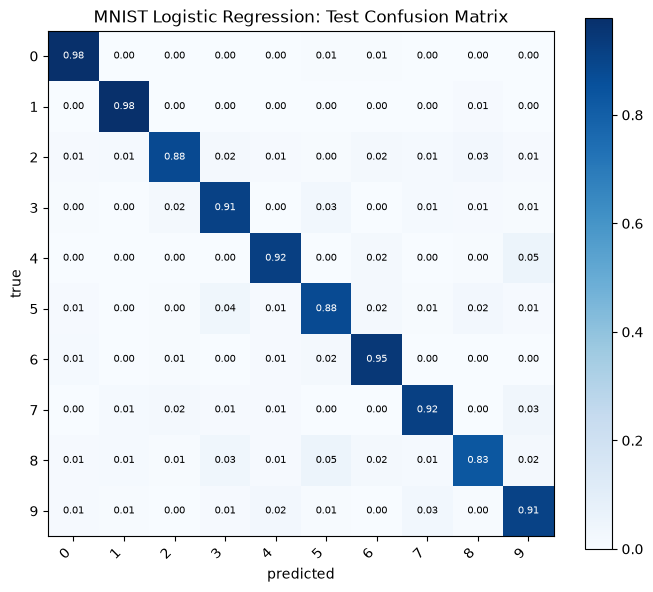

Per-class recall:
  0: 0.9786
  1: 0.9780
  2: 0.8818
  3: 0.9099
  4: 0.9185
  5: 0.8778
  6: 0.9468
  7: 0.9173
  8: 0.8316
  9: 0.9068
Top confusions (true -> predicted): [('4', '9', 51), ('8', '5', 49), ('8', '3', 34), ('5', '3', 32), ('7', '9', 32)]


In [40]:
y_true, y_pred = predict_all(mnist_lr_sgd, mnist_test_loader)
cm_mnist_test = confusion_matrix(y_true, y_pred)

plot_confusion(
    cm_mnist_test,
    classes=MNIST_CLASSES,
    normalize=True,
    title="MNIST Logistic Regression: Test Confusion Matrix",
)

recall = cm_mnist_test.diag().float() / cm_mnist_test.sum(1).clamp(min=1)
print("Per-class recall:")
for digit, value in enumerate(recall):
    print(f"  {digit}: {value.item():.4f}")
print("Top confusions (true -> predicted):", top_confusions(cm_mnist_test, MNIST_CLASSES, k=5))

The largest confusions were 4→9 (51 examples), 8→5 (49), 8→3 (34), 5→3 (32), and 7→9 (32). These pairs share overlapping curved strokes, loops, or open/closed shapes, so small changes in handwriting can make one digit resemble another. The weakest recalls were for 8 (83.16%), 5 (87.78%), and 2 (88.18%), while 0 and 1 were easiest to recognize at about 97.9% recall. Because the model uses a linear score on raw pixels, it cannot easily account for shifted or differently styled versions of the same digit.

### 1.6 · Noisy labels  *(0.5%)*

Flip **10% of the training labels** to a different random class, retrain the baseline, and report the
change in accuracy.

Two rules: only **training** labels get corrupted — validation and test stay clean, or you are measuring
nothing — and a flipped label must differ from the original, otherwise you have corrupted roughly 9%,
not 10%.

`RelabeledDataset` below serves images from a dataset with labels you supply. You build the label tensor.

flipped 1375 / 13750 = 0.100
MNIST LogReg|10% noisy labels|SGD|lr=0.01  (7,850 parameters)


/home/laurie/CMPUT328/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


epoch 01  train loss 1.1702 acc 0.707  |  val loss 0.5140 acc 0.877
epoch 02  train loss 0.9024 acc 0.799  |  val loss 0.4823 acc 0.886
epoch 03  train loss 0.8757 acc 0.810  |  val loss 0.4798 acc 0.894
epoch 04  train loss 0.8666 acc 0.809  |  val loss 0.4910 acc 0.890
epoch 05  train loss 0.8564 acc 0.811  |  val loss 0.4711 acc 0.894
epoch 06  train loss 0.8470 acc 0.817  |  val loss 0.4709 acc 0.892
epoch 07  train loss 0.8391 acc 0.815  |  val loss 0.4839 acc 0.892
epoch 08  train loss 0.8390 acc 0.817  |  val loss 0.4745 acc 0.897
epoch 09  train loss 0.8317 acc 0.817  |  val loss 0.4759 acc 0.897
epoch 10  train loss 0.8240 acc 0.819  |  val loss 0.4890 acc 0.893


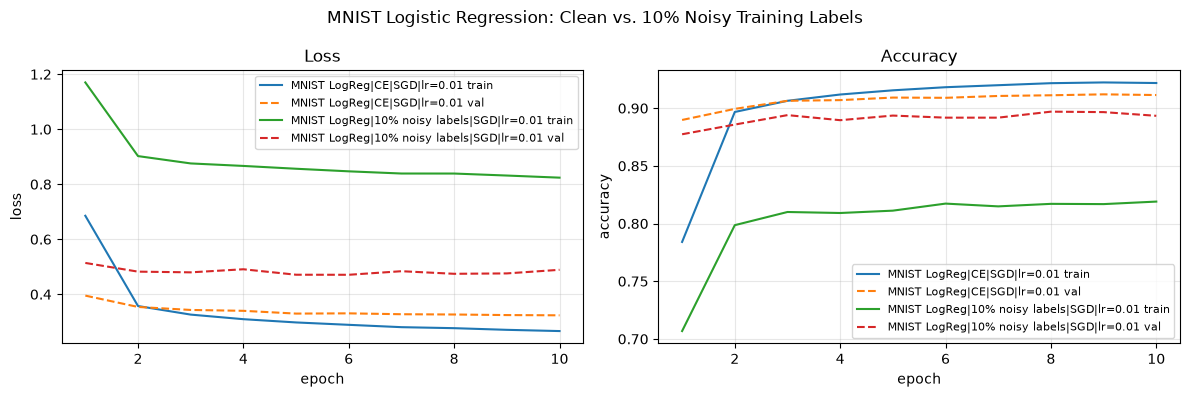

Clean final validation accuracy: 0.9114
Noisy final validation accuracy: 0.8934
Final validation accuracy change: -0.0180
Best validation accuracy change: -0.0150


In [41]:
class RelabeledDataset(Dataset):
    """Serves (image, label) from `base`, taking labels from `labels` instead of the originals."""
    def __init__(self, base, labels):
        assert len(base) == len(labels)
        self.base, self.labels = base, labels

    def __len__(self):
        return len(self.base)

    def __getitem__(self, i):
        x, _ = self.base[i]
        return x, int(self.labels[i])


clean_labels = get_targets(mnist_train_ds).clone()

noise_generator = torch.Generator().manual_seed(SEED)
num_flips = int(0.10 * len(clean_labels))
flip_indices = torch.randperm(len(clean_labels), generator=noise_generator)[:num_flips]
class_offsets = torch.randint(1, 10, (num_flips,), generator=noise_generator)
noisy_labels = clean_labels.clone()
noisy_labels[flip_indices] = (clean_labels[flip_indices] + class_offsets) % 10

flipped = noisy_labels != clean_labels
assert flipped.sum().item() == num_flips
print(f"flipped {flipped.sum().item()} / {len(clean_labels)} = {flipped.float().mean().item():.3f}")

noisy_train_loader = DataLoader(
    RelabeledDataset(mnist_train_ds, noisy_labels),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

mnist_lr_noisy, h_mnist_lr_noisy = build_and_fit(
    in_dim=28 * 28,
    train_loader=noisy_train_loader,
    val_loader=mnist_val_loader,
    optim_name="sgd",
    lr=LR["sgd"],
    epochs=EPOCHS_MNIST,
    label="MNIST LogReg|10% noisy labels|SGD|lr=0.01",
)

plot_curves(
    [h_mnist_lr_sgd, h_mnist_lr_noisy],
    title="MNIST Logistic Regression: Clean vs. 10% Noisy Training Labels",
)

clean_best = max(h_mnist_lr_sgd["val_acc"])
noisy_best = max(h_mnist_lr_noisy["val_acc"])
print(f"Clean final validation accuracy: {h_mnist_lr_sgd['val_acc'][-1]:.4f}")
print(f"Noisy final validation accuracy: {h_mnist_lr_noisy['val_acc'][-1]:.4f}")
print(f"Final validation accuracy change: {h_mnist_lr_noisy['val_acc'][-1] - h_mnist_lr_sgd['val_acc'][-1]:+.4f}")
print(f"Best validation accuracy change: {noisy_best - clean_best:+.4f}")

With exactly 10% of the training labels corrupted, final validation accuracy fell from 91.14% to 89.34%, a decrease of 1.80 percentage points. The best validation accuracy decreased by 1.50 points, which is smaller than the 10-point noise rate because 90% of the training labels remained correct and the linear model could still learn the common pixel patterns of each digit. The noisy model's training accuracy also stayed lower, reflecting the inconsistent targets it was trying to fit.

The MNIST baseline reached about 91% validation accuracy, showing that normalized raw pixels contain enough class-specific structure for a linear classifier to perform well. L1 and L2 regularization made almost no difference to validation accuracy at the tested strengths, but L1 produced the highest near-zero parameter fraction, so its main effect here was modest sparsity rather than better prediction. SGD improved faster during the early epochs, while Adam caught up and finished slightly higher, illustrating that optimizer choice mainly changed the path and speed for this convex logistic-regression objective. The learned weight templates contained rough digit-like strokes: positive regions supported a class and negative regions suppressed pixels associated with competing classes. The largest test errors, such as 4->9, 8->5, and 8->3, involved overlapping curves and loops that are difficult to separate using independent linear pixel weights, especially when handwriting is shifted or stylized. Finally, corrupting 10% of the training labels reduced final validation accuracy by 1.80 percentage points, a smaller drop than the noise rate because most labels stayed correct and the model could still learn the dominant digit patterns.

---
# PART 2 — CIFAR-10 with a Fully Connected Neural Network (5%)

Same pipeline, harder data: 3072 input dimensions, 10 object classes, and no spatial structure available
to the model once the image is flattened. **No CNNs in this assignment.**

### 2.1 · Fully connected neural network  *(0.5%)*

One argument changes: `hidden_sizes=(512,)`. The ReLU between the two linear layers is what makes the
model non-linear — without it, two stacked `nn.Linear` layers collapse into a single linear map and you
would be back to logistic regression with extra steps.

Train it, and report the parameter count next to the linear model's for comparison.

In [42]:
cifar_logreg_params = count_params(Classifier(3 * 32 * 32))

ffnn, h_ffnn = build_and_fit(
    in_dim=3 * 32 * 32,
    train_loader=train_loader,
    val_loader=val_loader,
    hidden_sizes=(512,),
    optim_name="adam",
    lr=LR["adam"],
    epochs=EPOCHS_CIFAR,
    label="CIFAR-10 FFNN|512 ReLU|Adam|lr=0.001",
)

print(f"CIFAR-10 LogReg parameters: {cifar_logreg_params:,}")
print(f"CIFAR-10 FFNN parameters: {count_params(ffnn):,}")

CIFAR-10 FFNN|512 ReLU|Adam|lr=0.001  (1,578,506 parameters)
epoch 01  train loss 1.7885 acc 0.382  |  val loss 1.6287 acc 0.439
epoch 02  train loss 1.5030 acc 0.480  |  val loss 1.6001 acc 0.444
epoch 03  train loss 1.3786 acc 0.522  |  val loss 1.5571 acc 0.465
epoch 04  train loss 1.2761 acc 0.561  |  val loss 1.6190 acc 0.458
epoch 05  train loss 1.2019 acc 0.586  |  val loss 1.5860 acc 0.477
epoch 06  train loss 1.1193 acc 0.613  |  val loss 1.5991 acc 0.476
epoch 07  train loss 1.0471 acc 0.637  |  val loss 1.6277 acc 0.468
epoch 08  train loss 0.9644 acc 0.672  |  val loss 1.6349 acc 0.487
epoch 09  train loss 0.8963 acc 0.694  |  val loss 1.6971 acc 0.473
epoch 10  train loss 0.8549 acc 0.711  |  val loss 1.7303 acc 0.474
epoch 11  train loss 0.8019 acc 0.730  |  val loss 1.7843 acc 0.477
epoch 12  train loss 0.7079 acc 0.764  |  val loss 1.7443 acc 0.486
CIFAR-10 LogReg parameters: 30,730
CIFAR-10 FFNN parameters: 1,578,506


### 2.2 · Training curves  *(0.25%)*

Plot training vs. validation loss and accuracy, and interpret them. Look for the epoch where validation
stops improving while training keeps going — the gap between the two curves is overfitting, and the extra
capacity of the hidden layer makes it show up sooner than it did on MNIST.

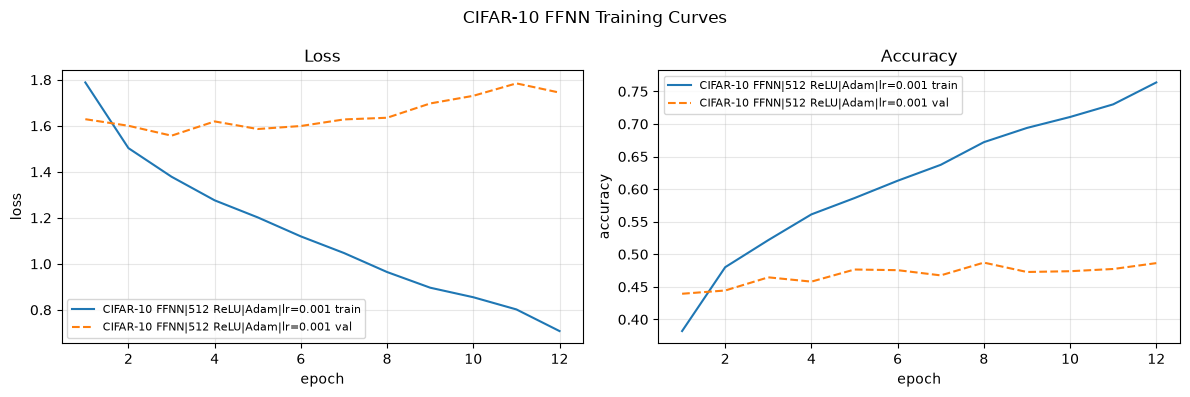

Final train accuracy: 0.7637
Final validation accuracy: 0.4864
Best validation accuracy: 0.4872 (epoch 8)
Final train-validation accuracy gap: 0.2773


In [43]:
plot_curves(h_ffnn, title="CIFAR-10 FFNN Training Curves")

ffnn_best_epoch = int(np.argmax(h_ffnn["val_acc"])) + 1
print(f"Final train accuracy: {h_ffnn['train_acc'][-1]:.4f}")
print(f"Final validation accuracy: {h_ffnn['val_acc'][-1]:.4f}")
print(
    f"Best validation accuracy: {max(h_ffnn['val_acc']):.4f} "
    f"(epoch {ffnn_best_epoch})"
)
print(f"Final train-validation accuracy gap: {h_ffnn['train_acc'][-1] - h_ffnn['val_acc'][-1]:.4f}")

The FFNN learned the training set steadily: training accuracy increased from 38.2% to 76.37% and training loss decreased throughout the 12 epochs. Validation accuracy improved more slowly and peaked at 48.72% in epoch 8 before fluctuating and ending at 48.64%, while validation loss generally increased after its early minimum. This divergence indicates overfitting, with a final train-validation accuracy gap of 27.73 percentage points. The gap appears because the large hidden layer can memorize training-specific pixel configurations without learning features that generalize well to new CIFAR-10 images.

### 2.3 · Confusion matrix on the validation set  *(0.25%)*

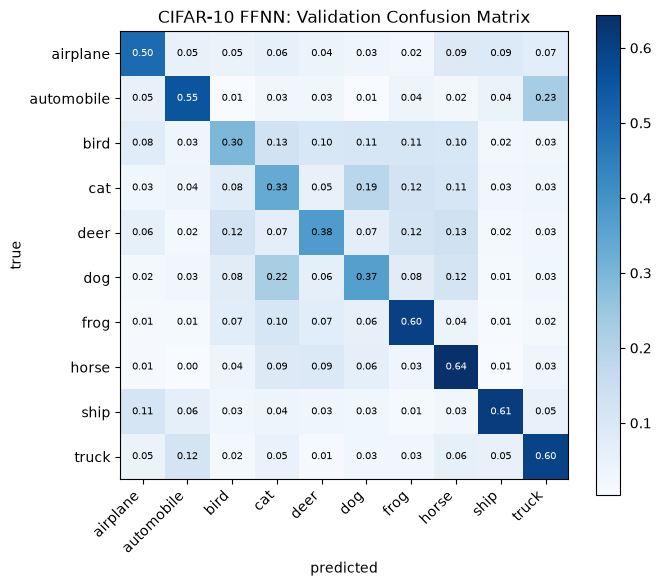

Per-class recall:
  airplane: 0.4979
  automobile: 0.5522
  bird: 0.2953
  cat: 0.3339
  deer: 0.3787
  dog: 0.3653
  frog: 0.6013
  horse: 0.6436
  ship: 0.6122
  truck: 0.5959
Top confusions (true -> predicted): [('automobile', 'truck', 113), ('dog', 'cat', 112), ('cat', 'dog', 104), ('cat', 'frog', 66), ('truck', 'automobile', 63)]


In [44]:
y_true_cifar, y_pred_cifar = predict_all(ffnn, val_loader)
cm_cifar_val = confusion_matrix(y_true_cifar, y_pred_cifar, num_classes=len(CLASSES))

plot_confusion(
    cm_cifar_val,
    classes=CLASSES,
    normalize=True,
    title="CIFAR-10 FFNN: Validation Confusion Matrix",
)

cifar_recall = cm_cifar_val.diag().float() / cm_cifar_val.sum(1).clamp(min=1)
print("Per-class recall:")
for class_name, value in zip(CLASSES, cifar_recall):
    print(f"  {class_name}: {value.item():.4f}")
print("Top confusions (true -> predicted):", top_confusions(cm_cifar_val, CLASSES, k=5))

The largest validation confusions were automobile->truck (113 examples), dog->cat (112), cat->dog (104), cat->frog (66), and truck->automobile (63). Automobile and truck share similar body shapes, road backgrounds, and colours, while cats and dogs have overlapping small-animal shapes and backgrounds; cats can also resemble frogs when the image is low-resolution or dominated by colour and texture. The weakest recalls were for bird (29.53%), cat (33.39%), dog (36.53%), and deer (37.87%), whereas horse reached 64.36% and ship 61.22%. These errors show that the flattened FFNN can use global colour and texture cues but lacks the spatially local features and translation tolerance that would help separate visually similar objects.

### 2.4 · Misclassification grid  *(0.25%)*

Display **at least 16** misclassified validation images with predicted and true labels (TODO 4).

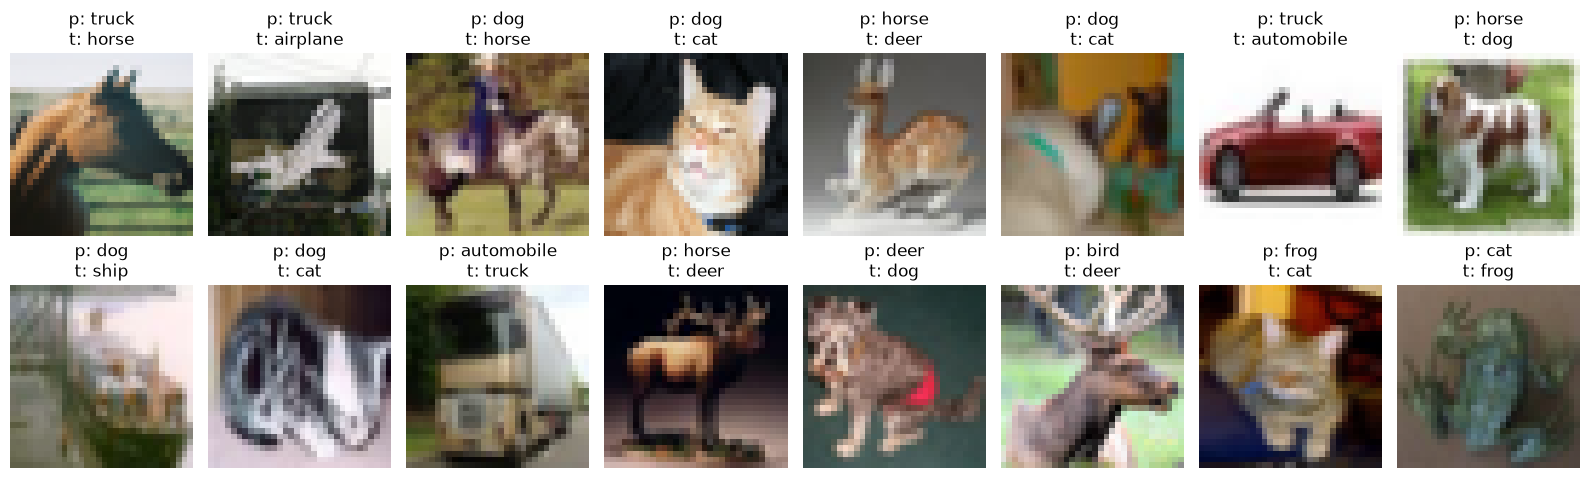

In [45]:
show_misclassified(ffnn, val_loader, n=16)

Many individual errors are explainable from the images: the truck/automobile mistakes have similar vehicle shapes, and the dog/cat/horse/deer mistakes often show small, blurred animals with overlapping silhouettes and backgrounds. Some examples are genuinely ambiguous even to a person because the 32x32 resolution hides fine details, while others appear visually recognizable but are still misclassified because the flattened FFNN cannot model local shapes and object position robustly. The grid therefore supports the confusion-matrix pattern of errors being driven by both semantic similarity and loss of spatial information.

### 2.5 · One deliberate modification  *(1.0%)*

Change **one** thing: hidden size, activation, learning rate, or number of epochs.

The marks are for the reasoning, not for the accuracy going up. **State your expectation in the cell
below before you run anything**, including *why* — then report what actually happened, especially if it
contradicts you.

**My change:** I reduced the hidden layer from 512 units to 256 units, keeping the data, Adam optimizer, learning rate, activation, and number of epochs unchanged.

**What I expect to happen, and why:** The smaller network should have less capacity to memorize training-specific pixel configurations, so I expect lower training accuracy but a smaller train-validation gap. Validation accuracy may improve slightly if the original model was overfitting, although it could also decrease if the smaller layer underfits the difficult CIFAR-10 data.

In [46]:
mod_model, h_mod = build_and_fit(
    in_dim=3 * 32 * 32,
    train_loader=train_loader,
    val_loader=val_loader,
    hidden_sizes=(256,),
    optim_name="adam",
    lr=LR["adam"],
    epochs=EPOCHS_CIFAR,
    label="CIFAR-10 FFNN|256 ReLU|Adam|lr=0.001",
)

CIFAR-10 FFNN|256 ReLU|Adam|lr=0.001  (789,258 parameters)
epoch 01  train loss 1.7863 acc 0.380  |  val loss 1.6584 acc 0.419
epoch 02  train loss 1.5176 acc 0.473  |  val loss 1.6170 acc 0.441
epoch 03  train loss 1.4006 acc 0.518  |  val loss 1.5824 acc 0.457
epoch 04  train loss 1.3123 acc 0.545  |  val loss 1.5616 acc 0.475
epoch 05  train loss 1.2407 acc 0.568  |  val loss 1.5999 acc 0.472
epoch 06  train loss 1.1786 acc 0.590  |  val loss 1.5512 acc 0.477
epoch 07  train loss 1.0978 acc 0.626  |  val loss 1.5977 acc 0.482
epoch 08  train loss 1.0226 acc 0.651  |  val loss 1.5720 acc 0.482
epoch 09  train loss 0.9620 acc 0.673  |  val loss 1.6407 acc 0.474
epoch 10  train loss 0.9116 acc 0.690  |  val loss 1.6612 acc 0.478
epoch 11  train loss 0.8591 acc 0.708  |  val loss 1.7223 acc 0.478
epoch 12  train loss 0.8003 acc 0.730  |  val loss 1.7606 acc 0.476


### 2.6 · Updated metrics and plots for the modified model  *(0.5%)*

Regenerate the Part 2 diagnostics for the modified configuration so the comparison is like-for-like:
curves against the original run, updated validation accuracy, and the confusion matrix.

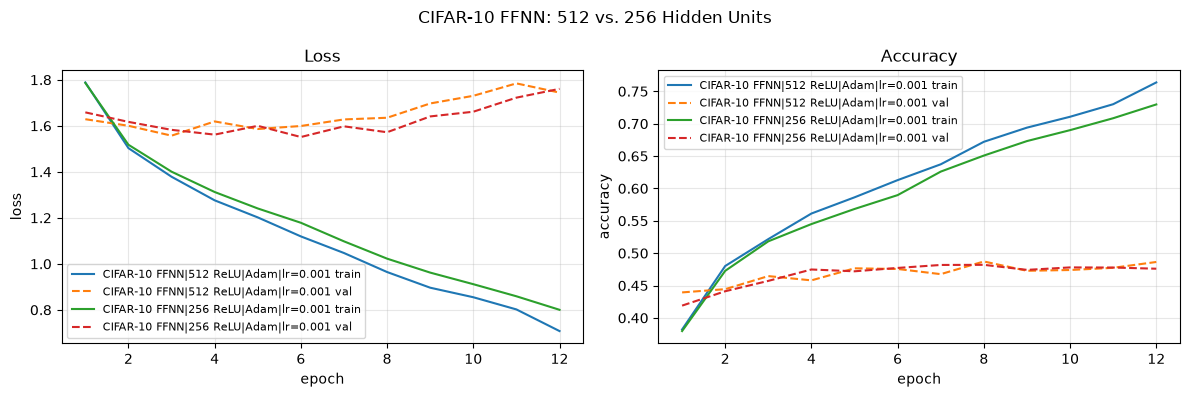

512-unit: final train acc=0.7637, final val acc=0.4864, best val acc=0.4872 (epoch 8), final gap=0.2773
256-unit: final train acc=0.7297, final val acc=0.4760, best val acc=0.4820 (epoch 8), final gap=0.2537


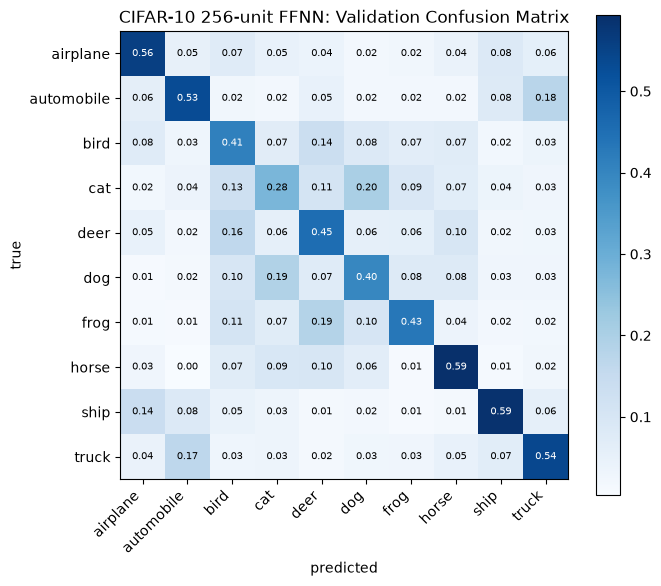

Modified-model top confusions: [('cat', 'dog', 113), ('dog', 'cat', 95), ('frog', 'deer', 89), ('truck', 'automobile', 89), ('automobile', 'truck', 88)]


In [47]:
plot_curves(
    [h_ffnn, h_mod],
    title="CIFAR-10 FFNN: 512 vs. 256 Hidden Units",
)

for label, history in [("512-unit", h_ffnn), ("256-unit", h_mod)]:
    best_epoch = int(np.argmax(history["val_acc"])) + 1
    gap = history["train_acc"][-1] - history["val_acc"][-1]
    print(
        f"{label}: final train acc={history['train_acc'][-1]:.4f}, "
        f"final val acc={history['val_acc'][-1]:.4f}, "
        f"best val acc={max(history['val_acc']):.4f} (epoch {best_epoch}), "
        f"final gap={gap:.4f}"
    )

mod_y_true, mod_y_pred = predict_all(mod_model, val_loader)
cm_mod = confusion_matrix(mod_y_true, mod_y_pred, num_classes=len(CLASSES))
plot_confusion(
    cm_mod,
    classes=CLASSES,
    normalize=True,
    title="CIFAR-10 256-unit FFNN: Validation Confusion Matrix",
)
print("Modified-model top confusions:", top_confusions(cm_mod, CLASSES, k=5))

Reducing the hidden layer from 512 to 256 units lowered final training accuracy from 76.37% to 72.97% and reduced the final train-validation gap from 27.73 to 25.37 percentage points, so the expectation of less memorization was supported. However, validation performance also decreased: best validation accuracy fell from 48.72% to 48.20%, and final validation accuracy fell from 48.64% to 47.60%. This indicates that the original model was overfitting but the smaller model also lost useful capacity, so the reduction did not improve generalization at these settings. The modified model still struggled with semantically similar classes, especially cat->dog, dog->cat, frog->deer, and truck<->automobile.

The 512-unit FFNN learned the training data strongly, reaching 76.37% training accuracy, but its validation accuracy peaked at only 48.72% and its final train-validation gap was 27.73 percentage points. The confusion matrix and misclassification grid show that the model relies on broad colour, texture, and silhouette cues: automobile and truck were frequently confused, as were dog and cat, while bird, cat, dog, and deer had the weakest recalls. Reducing the hidden layer to 256 units lowered the final gap to 25.37 points, confirming slightly less overfitting, but it also lowered best validation accuracy to 48.20%, so the smaller model lost useful capacity and did not improve generalization. Overall, the FFNN is limited because flattening removes the relationship between neighbouring pixels, gives no translation invariance, and forces the parameter count to grow with image size; a shifted object therefore activates a different collection of weights instead of being recognized through shared local features.

### 2.8 · Report  *(1.0%)*

Your 1–2 page PDF must cover, for a reader who has not seen this notebook:

1. Setup — datasets, splits, `FAST_MODE` setting, epochs, learning rates, what you held fixed
2. Regularization findings (L1 vs. L2)
3. SGD vs. Adam
4. Noisy-label findings
5. FFNN training dynamics
6. Confusion trends on both datasets
7. Effect of your modification — expectation vs. outcome
8. AI-assistance disclosure

If you used Gemini or another assistant, list representative prompts, what it produced, and what you
changed. Using one is allowed; submitting code you cannot explain is not — you may be asked to walk
through any cell.